<h1><center>TESLA Tutorial</center></h1>


<center>Author: Jian Hu*,  Kyle Coleman, Edward B. Lee, Humam Kadara, Linghua Wang*, Mingyao Li*

## Outline
#### 1. Installation
#### 2. Import modules
#### 3. Read in data
#### 4. Gene expression enhancement


### 1. Installation
To install TESLA package you must make sure that your python version is over 3.5.=. If you don’t know the version of python you can check it by:

In [ ]:
import platform
platform.python_version()

'3.11.13'

Note: Because TESLA pends on pytorch, you should make sure torch is correctly installed.
<br>
Now you can install the current release of TESLA by the following three ways:
#### 1.1 PyPI: Directly install the package from PyPI.

In [ ]:
pip3 install TESLAforST
#If you do not have permission (when you get a permission denied error), you should install TESLA by
pip3 install --user TESLAforST

#### 1.2 Github
Download the package from Github and install it locally:

In [ ]:
!git clone https://github.com/jianhuupenn/TESLA
cd ./TESLA/TESLA_package/
python3 setup.py install --user

#### 1.3 Anaconda ()
If you do not have Python3.5 or Python3.6 installed, consider installing Anaconda (see Installing Anaconda). After installing Anaconda, you can create a new environment, for example, TESLA (you can change to any name you like).

In [ ]:
#create an environment called TESLA
conda create -n TESLA python=3.7.9
#activate your environment 
conda activate TESLA
git clone https://github.com/jianhuupenn/TESLA
cd TESLA/TESLA_package/
python3 setup.py build
python3 setup.py install
conda deactivate

In [ ]:
!pip install pytz

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 2.3.2 requires tzdata>=2022.7, which is not installed.


### 2. Import python modules

In [ ]:
import os,csv,re, time
import pickle
import random
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from scipy import stats
from scipy.sparse import issparse
import scanpy as sc
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import cv2
import TESLA as tesla
from IPython.display import Image

In [ ]:
tesla.__version__

'1.2.2'

### 3. Read in data
The current version of TESLA requres three input data: 
<br>
1. The gene expression matrix(n by k): expression_matrix.h5;
<br>
2. Spatial coordinateds of samplespositions.txt;
<br>
3. Histology image(optional): histology.tif, can be tif or png or jepg.
<br>
The gene expreesion data can be stored as an AnnData object. AnnData stores a data matrix .X together with annotations of observations .obs, variables .var and unstructured annotations .uns. 

In [ ]:
#Read in gene expression and spatial location
counts=sc.read("data/adata_SCC_ST.h5ad")
#Read in hitology image
img=cv2.imread("data/GSM4284316_P2_ST_rep1.jpg")

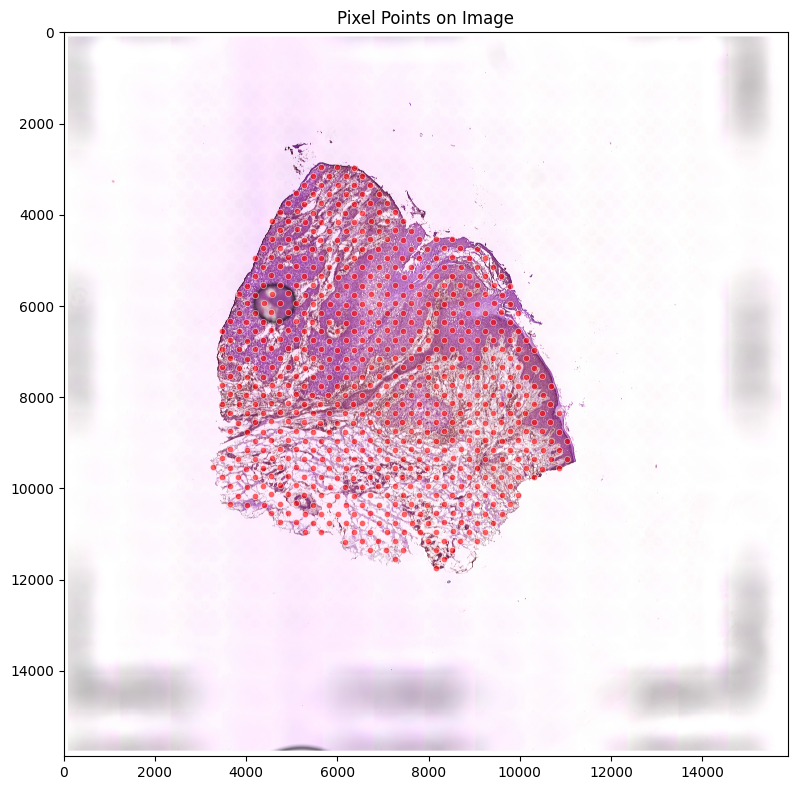

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
coords=counts.obs[['pixel_x',	'pixel_y']].values
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('on') 

plt.scatter(coords[:, 0], coords[:, 1], 
           s=20,           
           c='red',        
           alpha=0.6,      
           edgecolors='white',  
           linewidths=0.5) 

plt.title('Pixel Points on Image')
plt.tight_layout()
plt.show()

### 4. Gene expression enhancement

#### 4.1 Preprocessing

In [ ]:
resize_factor=1000/np.min(img.shape[0:2])
resize_width=int(img.shape[1]*resize_factor)
resize_height=int(img.shape[0]*resize_factor)
counts.var.index=[i.upper() for i in counts.var.index]
counts.var_names_make_unique()
counts.raw=counts
sc.pp.log1p(counts) # impute on log scale
if issparse(counts.X):counts.X=counts.X.A
counts.obs[["array_x", "array_y"]]=counts.obs[["x", "y"]]

#### 4.2 Contour detection

In [ ]:
#Three different algorithms to detect contour, select the best one.Here we use cv2.

#-----------------1. Detect contour using cv2-----------------
cnt=tesla.cv2_detect_contour(img, apertureSize=5,L2gradient = True)

binary=np.zeros((img.shape[0:2]), dtype=np.uint8)
cv2.drawContours(binary, [cnt], -1, (1), thickness=-1)
#Enlarged filter
cnt_enlarged = tesla.scale_contour(cnt, 1.05)
binary_enlarged = np.zeros(img.shape[0:2])
cv2.drawContours(binary_enlarged, [cnt_enlarged], -1, (1), thickness=-1)
img_new = img.copy()
cv2.drawContours(img_new, [cnt], -1, (255), thickness=50)
img_new=cv2.resize(img_new, ((resize_width, resize_height)))
cv2.imwrite('results/cnt.jpg', img_new)


True

#### 4.3 Gene expression enhancement

In [ ]:
#Set size of superpixel
res=50
# Note, if the numer of superpixels is too large and take too long, you can increase the res to 100
enhanced_exp_adata=tesla.imputation(img=img, raw=counts, cnt=cnt, genes=counts.var.index.tolist(), shape="None", res=res, s=1, k=2, num_nbs=10)

Total number of sudo points:  20946
Calculating spot 0
Calculating spot 1000
Calculating spot 2000
Calculating spot 3000
Calculating spot 4000
Calculating spot 5000
Calculating spot 6000
Calculating spot 7000
Calculating spot 8000
Calculating spot 9000
Calculating spot 10000
Calculating spot 11000
Calculating spot 12000
Calculating spot 13000
Calculating spot 14000
Calculating spot 15000
Calculating spot 16000
Calculating spot 17000
Calculating spot 18000
Calculating spot 19000
Calculating spot 20000
--- 62.218785524368286 seconds ---
Imputing spot 0
Imputing spot 1000
Imputing spot 2000
Imputing spot 3000
Imputing spot 4000
Imputing spot 5000
Imputing spot 6000
Imputing spot 7000
Imputing spot 8000
Imputing spot 9000
Imputing spot 10000
Imputing spot 11000
Imputing spot 12000
Imputing spot 13000
Imputing spot 14000
Imputing spot 15000
Imputing spot 16000
Imputing spot 17000
Imputing spot 18000
Imputing spot 19000
Imputing spot 20000


In [ ]:
img0=img.copy(); raw=counts.copy(); cnt0=cnt.copy

#### 4.4 Plot  gene expression image

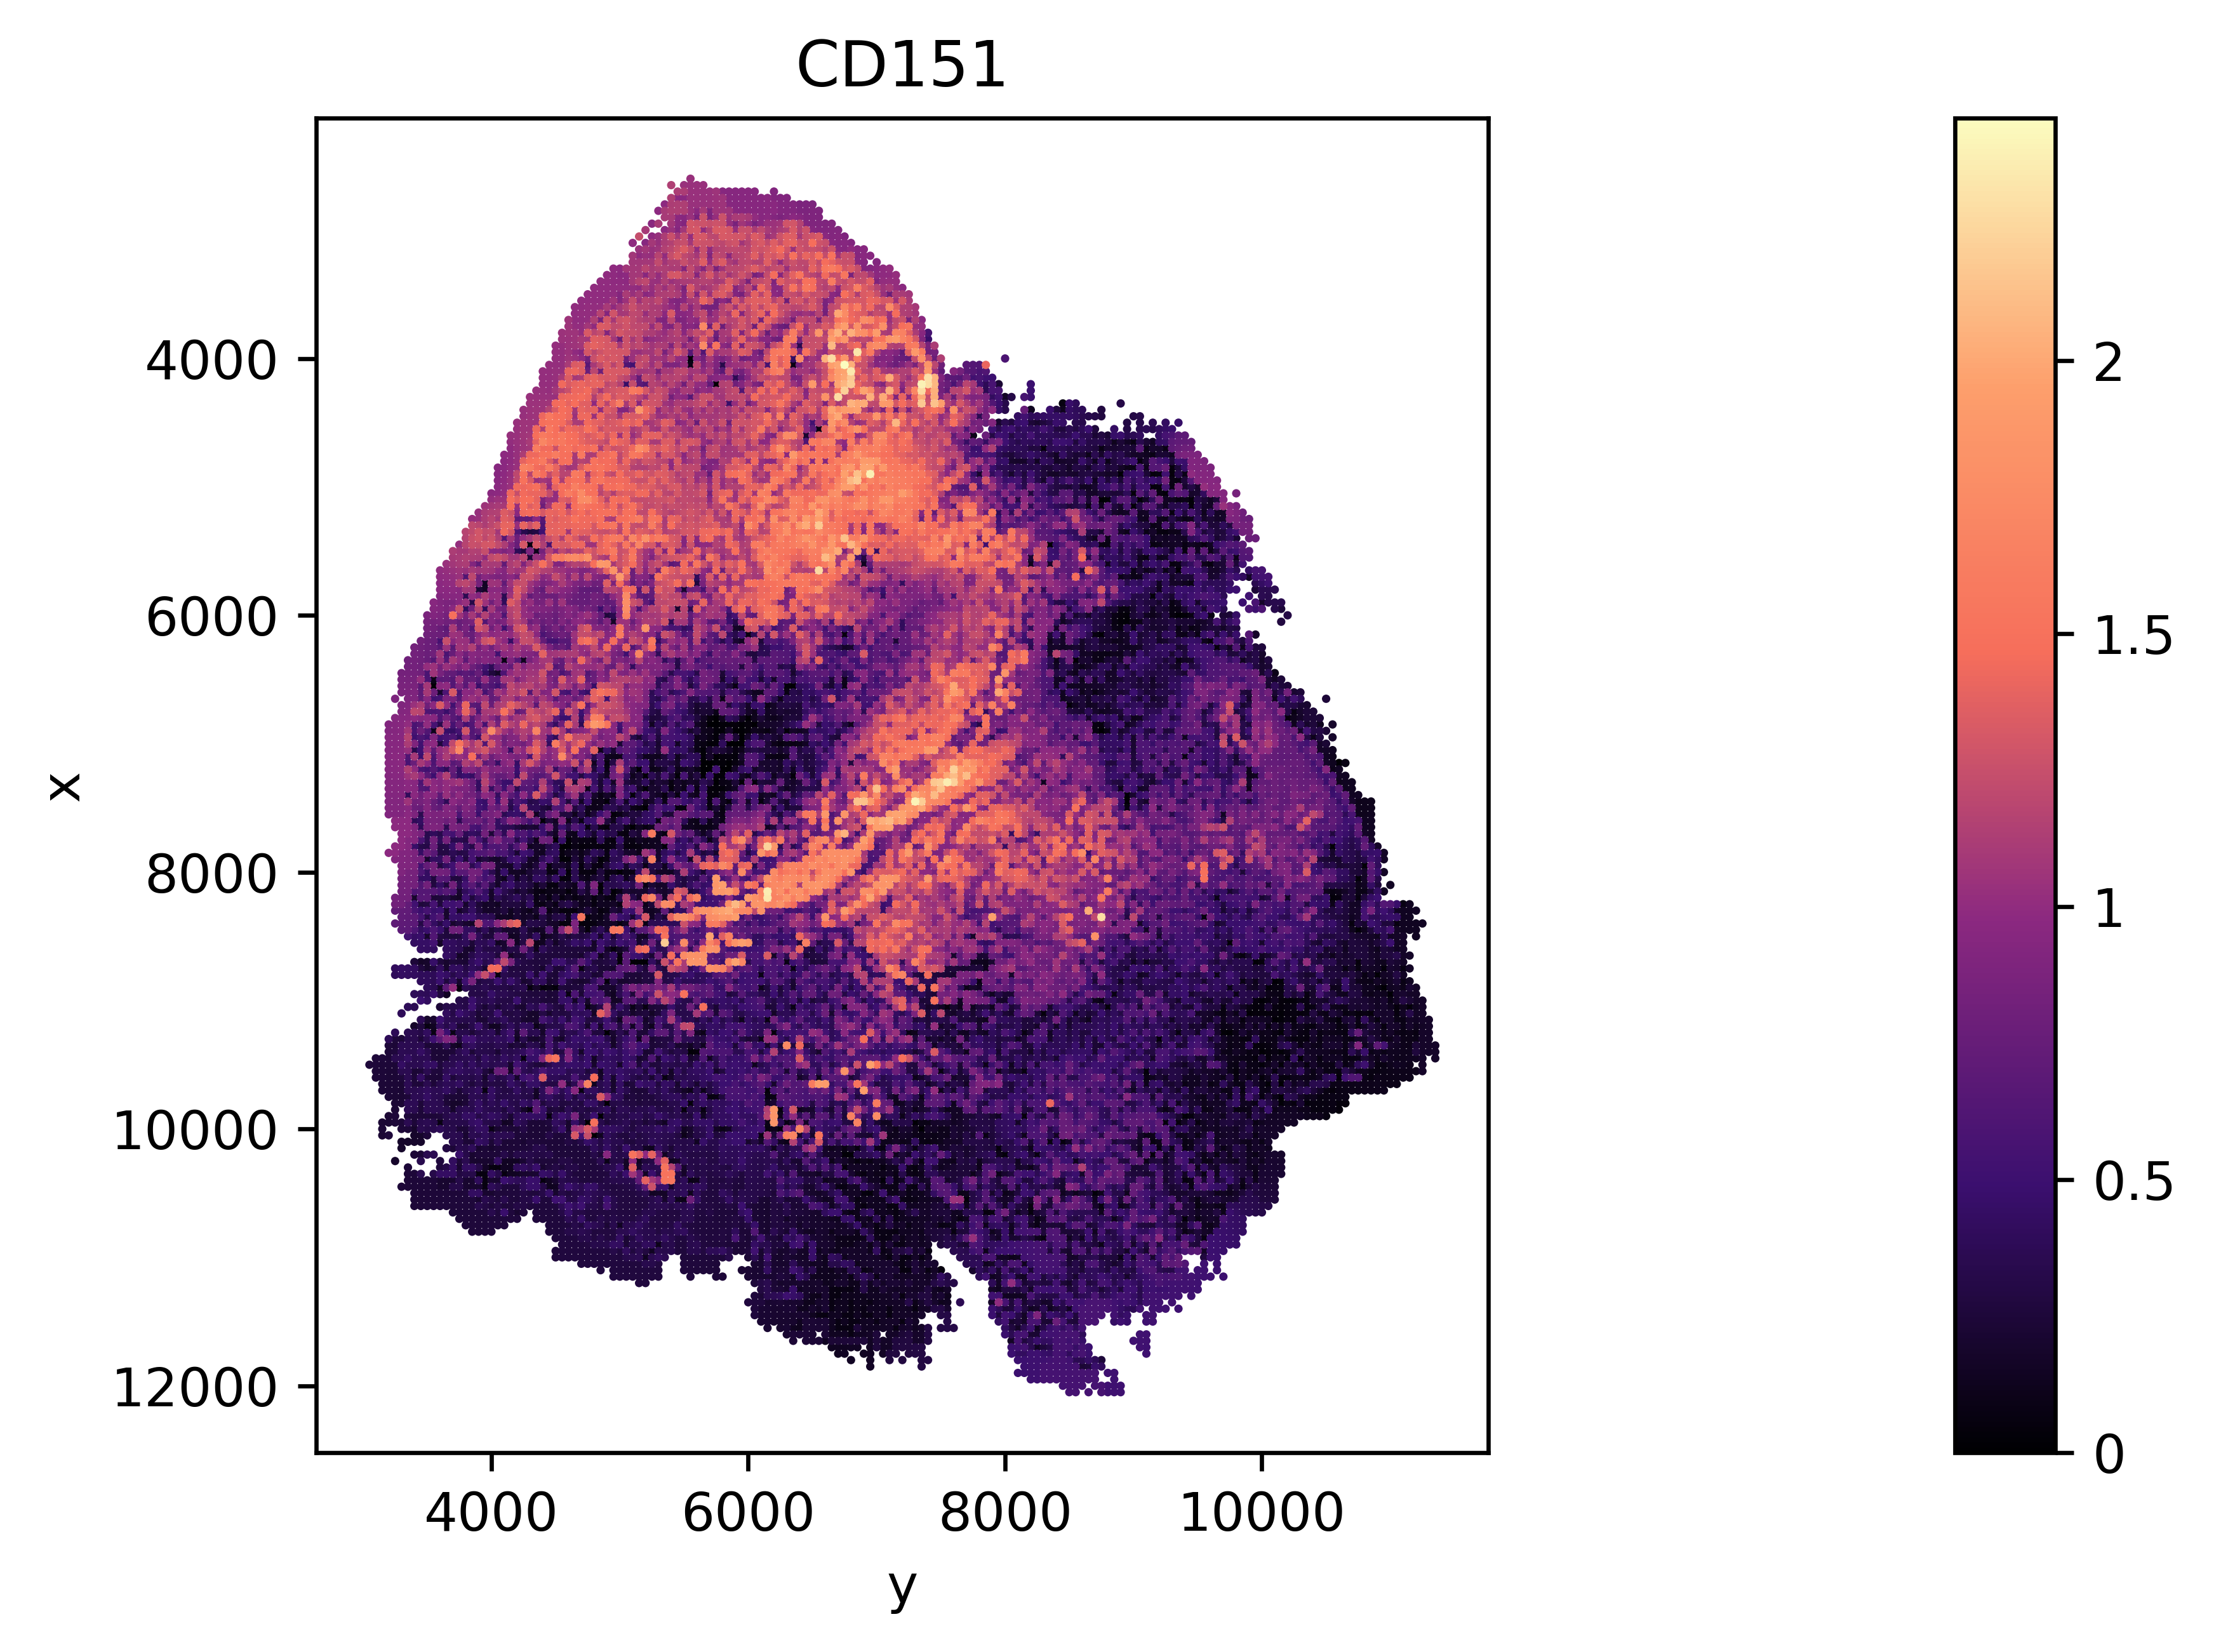

In [ ]:
cnt_color = clr.LinearSegmentedColormap.from_list('magma', ["#000003",  "#3b0f6f",  "#8c2980",   "#f66e5b", "#fd9f6c", "#fbfcbf"], N=256)
g="CD151"
enhanced_exp_adata.obs[g]=enhanced_exp_adata.X[:,enhanced_exp_adata.var.index==g]
fig=sc.pl.scatter(enhanced_exp_adata,alpha=1,x="y",y="x",color=g,color_map=cnt_color,show=False,size=10)
fig.set_aspect('equal', 'box')
fig.invert_yaxis()
plt.gcf().set_dpi(600)
fig.figure.show()

In [ ]:
enhanced_exp_adata.obs

,x,y,color,z,CD151,meta
0,2600,5550,242.406644,3462.297972,1.032458,0.422405
1,2650,5400,241.183135,3397.850194,1.136948,0.465155
2,2650,5500,242.328476,3458.180522,1.033144,0.422686
3,2650,5550,243.430308,3516.219023,1.035373,0.423598
4,2650,5600,242.100172,3446.154708,1.033053,0.422649
...,...,...,...,...,...,...
20941,12050,8650,248.685914,3793.055599,0.551267,0.225538
20942,12050,8750,250.523971,3889.874435,0.554617,0.226908
20943,12050,8800,251.442352,3938.249711,0.511103,0.209106
20944,12050,8850,251.734655,3953.646648,0.510644,0.208918


In [ ]:
counts.obs

,x,y,new_x,new_y,pixel_x,pixel_y
7x45,7,45,6.98,44.94,3282.6,9536.7
8x30,8,30,8.04,29.98,3473.4,6539.5
8x32,8,32,8.03,31.97,3471.9,6937.9
8x34,8,34,8.04,33.97,3474.1,7338.8
8x36,8,36,8.01,35.96,3469.5,7736.4
...,...,...,...,...,...,...
49x41,49,41,48.90,41.06,10850.2,8757.7
49x43,49,43,48.97,43.04,10861.3,9155.9
49x45,49,45,48.91,45.05,10850.9,9557.6
50x42,50,42,49.98,42.05,11044.2,8956.9


#### 4.5 Save results

In [ ]:
enhanced_exp_adata.write_h5ad("results/enhanced_exp.h5ad")

### mapping the enhanced to original

In [ ]:
points1=counts.obs[['pixel_x','pixel_y']].to_numpy()
points2=enhanced_exp_adata.obs[['y','x']].to_numpy()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def find_nearest_rows_vectorized(points1, points2):
    if points1.shape[1] != 2 or points2.shape[1] != 2:
        raise ValueError("Shape should  be same")
    points1_expanded = points1[:, np.newaxis, :]  
    points2_expanded = points2[np.newaxis, :, :]  
    squared_distances = np.sum((points1_expanded - points2_expanded) ** 2, axis=2)  
    nearest_indices = np.argmin(squared_distances, axis=1)
    nearest_distances = np.sqrt(np.min(squared_distances, axis=1))
    return nearest_indices, nearest_distances


nearest_indices, nearest_distances = find_nearest_rows_vectorized(points1, points2)
enhanced_mapping=enhanced_exp_adata[nearest_indices,:]
enhanced_mapping.write_h5ad("results/enhanced_mapping.h5ad")